In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [2]:
stocks = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]

data = yf.download(stocks, start="2020-01-01", end="2025-01-01")
data = data["Close"].dropna()

data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-02,72.400513,94.900497,67.920815,152.158417,5.971077
2020-01-03,71.696640,93.748497,67.565483,150.263763,5.875506
2020-01-06,72.267929,95.143997,69.366386,150.652130,5.900144
2020-01-07,71.928047,95.343002,69.232391,149.278564,5.971576
2020-01-08,73.085106,94.598503,69.725174,151.656311,5.982775


In [3]:
data.to_csv("../data/raw_stock_prices.csv")

In [4]:
returns = data.pct_change().dropna()
returns.to_csv("../data/daily_returns.csv")
returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-03,-0.009722,-0.012139,-0.005232,-0.012452,-0.016006
2020-01-06,0.007968,0.014886,0.026654,0.002585,0.004193
2020-01-07,-0.004703,0.002092,-0.001932,-0.009117,0.012107
2020-01-08,0.016086,-0.007809,0.007118,0.015928,0.001875
2020-01-09,0.021241,0.004799,0.010498,0.012493,0.010983


In [5]:
trading_days = 252

annual_return = returns.mean() * trading_days
annual_volatility = returns.std() * np.sqrt(trading_days)

risk_free_rate = 0.02
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

annual_return, annual_volatility, sharpe_ratio

(Ticker
 AAPL     0.297892
 AMZN     0.232658
 GOOGL    0.257607
 MSFT     0.248931
 NVDA     0.768567
 dtype: float64,
 Ticker
 AAPL     0.316786
 AMZN     0.359639
 GOOGL    0.324989
 MSFT     0.304972
 NVDA     0.538788
 dtype: float64,
 Ticker
 AAPL     0.877222
 AMZN     0.591310
 GOOGL    0.731125
 MSFT     0.750661
 NVDA     1.389352
 dtype: float64)

In [6]:
cumulative_returns = (1 + returns).cumprod()
rolling_max = cumulative_returns.cummax()
drawdown = cumulative_returns / rolling_max - 1
max_drawdown = drawdown.min()

max_drawdown

Ticker
AAPL    -0.314273
AMZN    -0.561453
GOOGL   -0.443200
MSFT    -0.371485
NVDA    -0.663351
dtype: float64

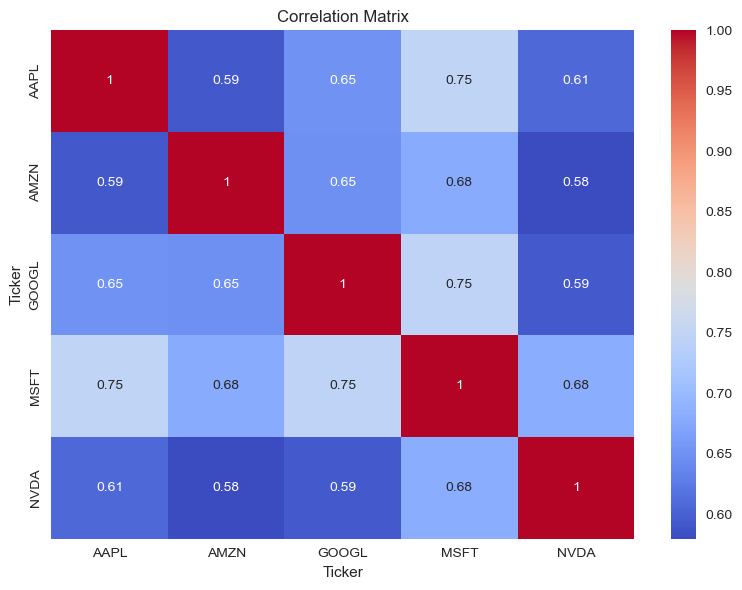

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("../visuals/correlation_matrix.png")
plt.show()

In [8]:
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)
    weights_record.append(weights)

    portfolio_return = np.sum(weights * annual_return)
    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(returns.cov() * 252, weights))
    )
    sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility

    results[0,i] = portfolio_return
    results[1,i] = portfolio_volatility
    results[2,i] = sharpe

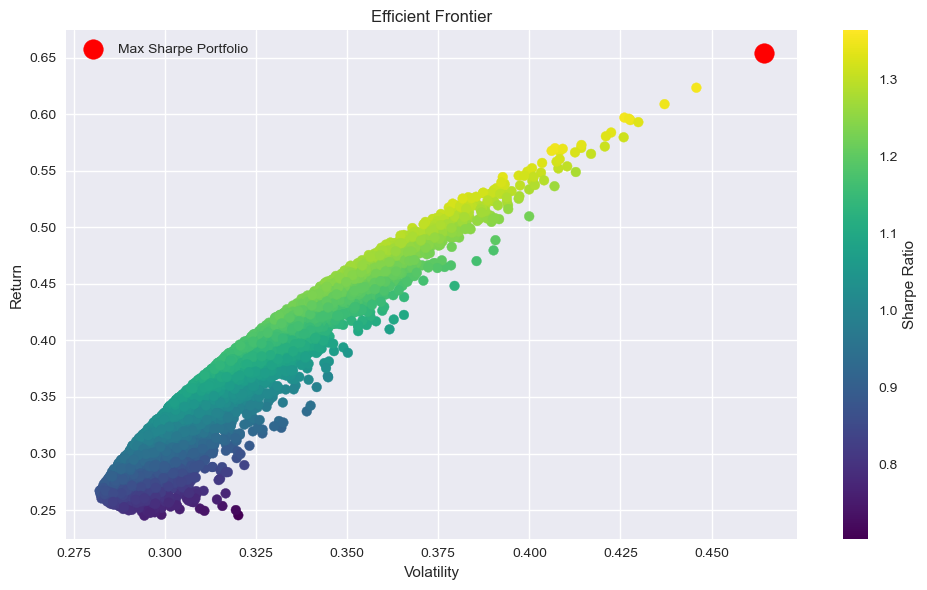

In [9]:
portfolio_df = pd.DataFrame(results.T, columns=["Return", "Volatility", "Sharpe"])

max_sharpe_idx = portfolio_df["Sharpe"].idxmax()
max_sharpe_portfolio = portfolio_df.loc[max_sharpe_idx]
optimal_weights = weights_record[max_sharpe_idx]

plt.figure(figsize=(10,6))
plt.scatter(portfolio_df["Volatility"], portfolio_df["Return"], c=portfolio_df["Sharpe"], cmap="viridis")
plt.colorbar(label="Sharpe Ratio")

plt.scatter(max_sharpe_portfolio["Volatility"],
            max_sharpe_portfolio["Return"],
            color="red",
            s=200,
            label="Max Sharpe Portfolio")

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.legend()
plt.tight_layout()
plt.savefig("../visuals/efficient_frontier.png")
plt.show()

In [10]:
print("===== OPTIMAL PORTFOLIO =====")
print(max_sharpe_portfolio)

print("\nOptimal Weights:")
for stock, weight in zip(stocks, optimal_weights):
    print(f"{stock}: {round(weight,4)}")

===== OPTIMAL PORTFOLIO =====
Return        0.653614
Volatility    0.464392
Sharpe        1.364396
Name: 3724, dtype: float64

Optimal Weights:
AAPL: 0.0992
MSFT: 0.1072
NVDA: 0.0209
GOOGL: 0.0002
AMZN: 0.7724
